# E-commerce Data Analysis and Rating Prediction

This project analyzes an e-commerce dataset containing user ratings, product reviews, and product information. The objective of the analysis is to explore user behavior, understand relationships between variables, and build machine learning models to predict product ratings.

The project begins with data preprocessing and cleaning to handle missing values and remove low-quality records. Descriptive statistics and visualizations are then used to explore patterns in the dataset, such as how ratings vary across different user attributes and product categories.

In the second stage of the project, correlation analysis and machine learning techniques are applied. Linear regression models are developed using different combinations of features and varying training dataset sizes to evaluate their predictive performance. The models are compared using evaluation metrics such as Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).

The results provide insights into how feature selection and training data size influence model performance and demonstrate a basic workflow for data analysis and predictive modeling using Python.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib inline

### Load Dataset

In [6]:
df = pd.read_csv('cleaned_ecommerce_dataset.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2685, 11)


,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4


In [8]:
df.info

<bound method DataFrame.info of       userId  timestamp                                           review  \
0       4081      71900                                Not always McCrap   
1       4081      72000  I dropped the chalupa even before he told me to   
2       4081      72000                     The Wonderful World of Wendy   
3       4081     100399                             They actually did it   
4       4081     100399                             Hey! Gimme some pie!   
...      ...        ...                                              ...   
2680    2445      22000                                     Great movie!   
2681    2445      30700                                       Good food!   
2682    2445      61500                                     Great movie!   
2683    2445     100500                                    Awesome Game.   
2684    2445     101400                                   Great Service.   

                                           item  rating

### Encode Categorical Variables

In [10]:
ord_enc = OrdinalEncoder()

df[['gender','review','category','helpfulness']] = ord_enc.fit_transform(
    df[['gender','review','category','helpfulness']]
)

### Correlation Analysis

In [16]:
correlation = df[['gender','review','category','helpfulness','rating']].corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
               gender    review  category  helpfulness    rating
gender       1.000000 -0.037884  0.022549     0.075947 -0.034337
review      -0.037884  1.000000  0.001970    -0.028259 -0.036118
category     0.022549  0.001970  1.000000    -0.013408 -0.163158
helpfulness  0.075947 -0.028259 -0.013408     1.000000 -0.007523
rating      -0.034337 -0.036118 -0.163158    -0.007523  1.000000


### Define features and target 

In [19]:
X = df[['gender','review','category','helpfulness']]
y = df[['rating']]

### Train-Test Split

In [33]:
# Case 1 – 10% training data
X_train_case1, X_test_case1, y_train_case1, y_test_case1 = train_test_split(
    X, y, test_size=0.9, random_state=42
)

# Case 2 – 90% training data
X_train_case2, X_test_case2, y_train_case2, y_test_case2 = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [44]:
print("Case 1 Training shape:", X_train_case1.shape)
print("Case 1 Testing shape:", X_test_case1.shape)

print("Case 2 Training shape:", X_train_case2.shape)
print("Case 2 Testing shape:", X_test_case2.shape)

Case 1 Training shape: (268, 4)
Case 1 Testing shape: (2417, 4)
Case 2 Training shape: (2416, 4)
Case 2 Testing shape: (269, 4)


### Model Training

In [36]:
models = {
    'model-a': {
        'X_train': X_train_case1[['helpfulness','review']],
        'X_test': X_test_case1[['helpfulness','review']],
        'y_train': y_train_case1,
        'y_test': y_test_case1
    },
    
    'model-b': {
        'X_train': X_train_case1[['gender','category']],
        'X_test': X_test_case1[['gender','category']],
        'y_train': y_train_case1,
        'y_test': y_test_case1
    },
    
    'model-c': {
        'X_train': X_train_case2[['helpfulness','review']],
        'X_test': X_test_case2[['helpfulness','review']],
        'y_train': y_train_case2,
        'y_test': y_test_case2
    },
    
    'model-d': {
        'X_train': X_train_case2[['gender','category']],
        'X_test': X_test_case2[['gender','category']],
        'y_train': y_train_case2,
        'y_test': y_test_case2
    }
}

### Model Evaluation

In [38]:
mse_values = {}
rmse_values = {}

for model_name, data in models.items():
    
    model = LinearRegression()
    model.fit(data['X_train'], data['y_train'])
    
    y_pred = model.predict(data['X_test'])
    
    mse = mean_squared_error(data['y_test'], y_pred)
    rmse = np.sqrt(mse)
    
    mse_values[model_name] = mse
    rmse_values[model_name] = rmse
    
    print(model_name)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print()

model-a
MSE: 1.8275341162748118
RMSE: 1.3518632017607446

model-b
MSE: 1.8076399168603041
RMSE: 1.3444850006081526

model-c
MSE: 1.7315431520816085
RMSE: 1.3158811314406818

model-d
MSE: 1.676233004232451
RMSE: 1.294694174016571



### Visualization of Model Performance

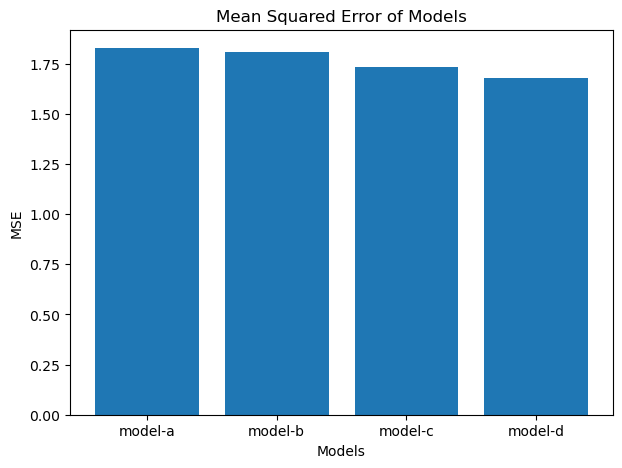

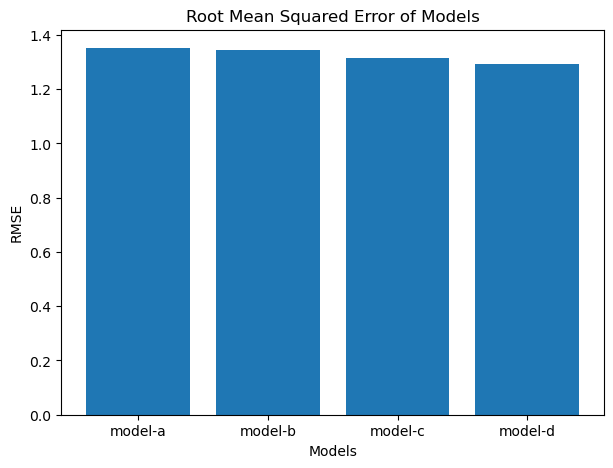

In [41]:
model_names = list(mse_values.keys())
mse_list = list(mse_values.values())
rmse_list = list(rmse_values.values())

plt.figure(figsize=(7,5))
plt.bar(model_names, mse_list)
plt.title("Mean Squared Error of Models")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.show()

plt.figure(figsize=(7,5))
plt.bar(model_names, rmse_list)
plt.title("Root Mean Squared Error of Models")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.show()

### Analysis of Model Performance

The bar charts compare the Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) values of the four regression models. Lower MSE and RMSE values indicate better model performance.

From the results, Model C achieves the lowest MSE and RMSE values, indicating the best predictive accuracy among the models. Model D also performs well but slightly worse than Model C. Both of these models were trained using a larger portion of the dataset (90% training data), which likely allowed them to learn more patterns from the data.

In contrast, Model A and Model B were trained with only 10% of the dataset, which may have limited their ability to capture important relationships within the data. Model A performs slightly better than Model B because it uses features with stronger correlations to the target variable.

Overall, the results support the expectation that models trained with more data and more relevant features tend to produce more accurate predictions.